# Identification
Please indicate your name

Student 1: Daria SHTYKA

Student 2: Charles DELEMOLLE

# Practical work 2 : Fourier transform

This practial work is dedicated to the study of the discrete Fourier transform applied on the two following images:
![son.png](./img/son.png)
![sonrot.png](./img/sonrot.png)
and analyze the properties of their spectrum. To this end, we make use of the following functions provided by the module `numpy.fft`:

- `fft2()` to compute the Fourier transform on an image
- `fftshift()` to center the low frequencies
- `abs()` (from `numpy`) to compute the module of a complexe array

In most of cases, high frequencies have lower energy compare to low frequencies. We will use a logarithmic scale by applying $\log(1+abs(TF))$ to display the spectrum.

In [1]:
import numpy as np
from numpy.fft import fft2,fftshift
from PIL import Image

son = np.array(Image.open('img/son.png'))
sonrot = np.array(Image.open('img/sonrot.png'))

## Exercise: properties of Fourier transform applied on natural images
1. Write the following functions:
 - `computeFT(I)` returning the Fourier transform of image `I`,
 - `toVisualizeFT(If)` returning the centered module of a complex array `If` (the Fourier transform of an image),
 - `toVisualizeLogFT(If)` similar to the previous function but use a logarithmic scale.

In [ ]:
def computeFT(I):
    """ Array -> Array[complex] """
    return fft2(I)

def toVisualizeFT(If):
    """ Array[complex] -> Array[float] """
    return np.abs(fftshift(If))


def toVisualizeLogFT(If):
    """ Array[complex] -> Array[float] """
    return np.log(1+np.abs(fftshift(If)))
    # return (np.log(1+toVisualizeFT(If)))

# toVisualizeLogFT(son)

/var/folders/d3/_3prq75j4zs7ww42zcnxc6bw0000gn/T/ipykernel_3490/3406439817.py:12: RuntimeWarning: divide by zero encountered in log
  return np.log(1+np.abs(fftshift(If)))


array([[-inf, -inf, -inf, ..., -inf, -inf, -inf],
       [-inf, -inf, -inf, ..., -inf, -inf, -inf],
       [-inf, -inf, -inf, ..., -inf, -inf, -inf],
       ...,
       [-inf, -inf, -inf, ..., -inf, -inf, -inf],
       [-inf, -inf, -inf, ..., -inf, -inf, -inf],
       [-inf, -inf, -inf, ..., -inf, -inf, -inf]],
      shape=(512, 512), dtype=float16)

2. Write a series of instructions that
 - compute the Fourier transform of `son` and `sonrot`,
 - compute and display the module using a logarithmic scale,
 - threshold the module with a parameter of $1.10^5$ (use the function of TME1)
 - display the thresholded spectrum

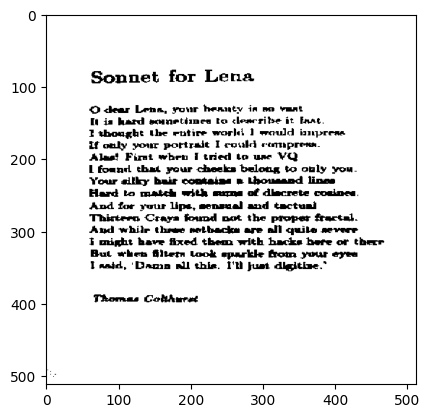

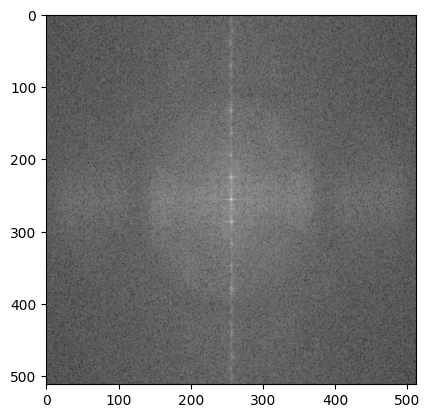

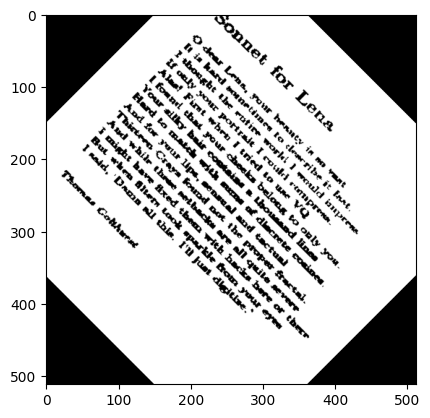

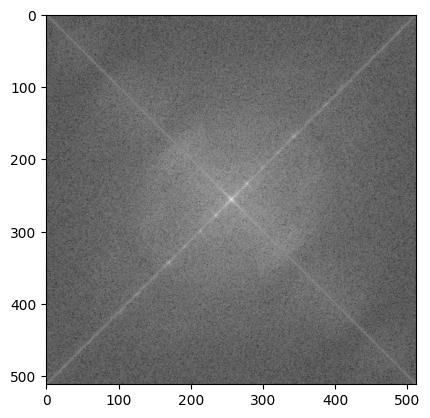

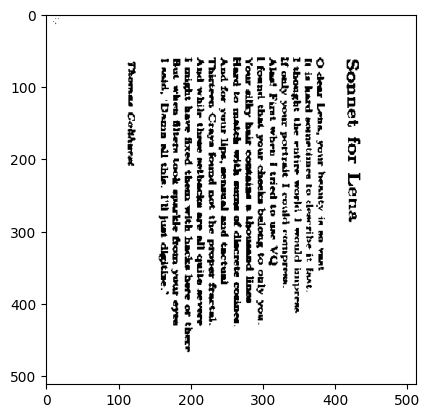

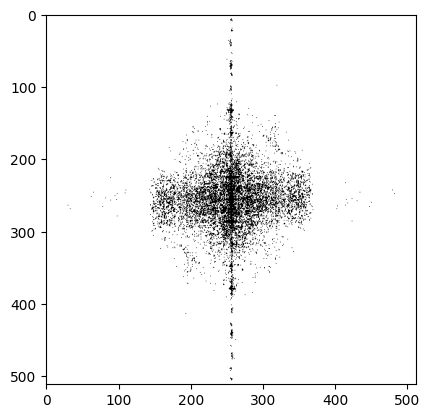

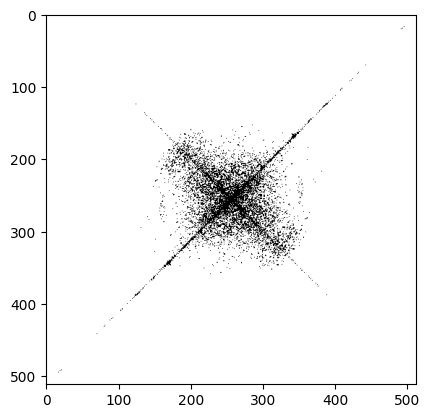

In [70]:
import matplotlib.pyplot as plt

# compute and display the log sclae
son_fft = computeFT(son)
sonrot_fft = computeFT(sonrot)
son_log = toVisualizeLogFT(son_fft)
sonrot_log = toVisualizeLogFT(sonrot_fft)
plt.gray()
plt.imshow(son)
plt.show()
plt.imshow(son_log)
plt.show()
plt.imshow(sonrot)
plt.show()
plt.imshow(sonrot_log)
plt.show()

# threshold
def thresholdImage(I,s):
    """ Array*int -> Array """
    new_array = np.copy(I)
    for i in range(I.shape[0]):
        for j in range(I.shape[1]):
           if I[i][j] <=s:
                 new_array[i][j] = 0
           else:
            new_array[i][j] = 255
    return new_array

# son_th= thresholdImage(son_log, 1.10 ** 5)
# sonrot_th= thresholdImage(sonrot_log, 1.10 ** 5)
# plt.imshow(son_th)
# plt.show()
# plt.imshow(sonrot_th)
# plt.show()
# print(son_log)

# une rotation pour comprendre le TF
sonrot_90 = np.rot90(son, k=3)
plt.imshow(sonrot_90)
plt.show()

# attention à mettre un parametre assez grand pour voir la difference
plt.gray() #pour mettre tout en gris
plt.imshow((son_log<(11.10 )))
plt.show()
plt.gray() #pour mettre tout en gris
plt.imshow((sonrot_log<(11.10 )))
plt.show()




3. Interpretation: discuss the results obtained on thresholded FT module. What property of the Fourier transform is shown ?

La propriété de rotation est observée. Note du cours "A rotation of angle θ in the spatial domain induces the same
rotation in the frequency domain".

Concernant les résultats, on sait déjà que dans l'image une structure étendue dans une direction présente un spectre plus concentré dans la direction perpendiculaire. 
Dans l'image originale, les lignes de texte sont horizontales et concetrés. Sur le spectre, on observe alors une dispersion verticale des fréquences. Inversement l'ensemble du texte est dispérsé horizontalement. Sur le spectre, on observe alors une concetration verticale des fréquences.


4. Write the function `blend()` getting two images, one float parameter $\alpha\in[0,1]$, calculating $\alpha I_1+(1-\alpha)I_2$ and returning the result. 

In [26]:
def blend(I1,I2,alpha):
    """ Array**2*float -> Array """
    return alpha*I1 + (1-alpha)*I2

5. Apply the previous function on images `son` and `sonrot` and $\alpha=\frac12$, compute the Fourier transform, threshold the module and visualize the result. 

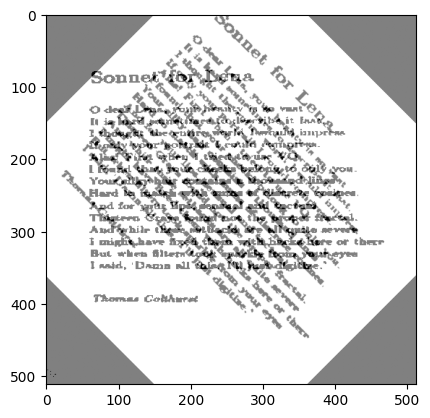

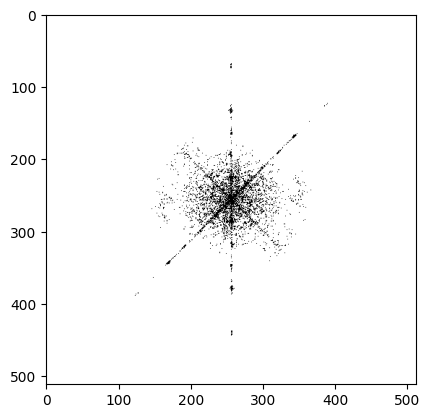

In [142]:
son_sonrot = blend(son, sonrot, 1/2)
plt.imshow(son_sonrot)
plt.show()
#compute the Fourier transform
son_sonrot_FT = computeFT(son_sonrot)
# module
son_sonrot_FTMOD = toVisualizeLogFT(son_sonrot_FT)
# print(son_sonrot_FTMOD)

#threshold the module and visualize the result
plt.gray()
plt.imshow(son_sonrot_FTMOD<11.10)
plt.show()


6. Compare the latter result with those of question 2: what property of the Fourier transform is shown? What is the behaviour of $\alpha$ in the resulting spectrum?

On peut observer la combinaison linéaire de nos deux spéctres de la question d'avant. Ceci est la linéartite ( alpha*I1 + (1-alpha)*I2 == aX (f ) + bY (f ) ) .

7. We want to determine the text orientation in image `sonrot` and produce a new image with horizontal text. Write the function `rectifyOrientation()` that:

 + computes the FT module of image given in parameter and threshold it at $3\times 10^{5}$,
 + from thresholded module determines the main orientation using the function `mainOrientation()` 
 + produces the rectified image applying a rotation with a suitable angle using `rotateImage()`

In [143]:
def mainOrientation(I):
    """ Array -> tuple[Iori,float]
        return image of orientation (32 bins) and the main orientation (degree) from a Fourier transform module
    """
    n, m = I.shape

    size = 32
    x = np.array(range(size))
    ori = np.vstack((np.cos(np.pi*x/size), np.sin(np.pi*x/size))).T

    Iori = np.zeros((n, m))
    orients = np.zeros((size))

    for i in range(1,n+1):
        for j in range(1,m+1):
            if I[i-1, j-1] > 0:
                v = np.array([j-m/2, -i + n/2])
                if i > n/2:
                    v = -v
                    prod = np.matmul(ori, v)
                    maxi = prod.max()
                    if maxi > 0:
                        imax = np.nonzero(prod == maxi)
                        Iori[i-1, j-1] = imax[0][0]
                        orients[imax] += 1

    maxori = np.nonzero(orients == orients.max())[0][0]
    return (Iori, 180*maxori/size - 90)

def rotateImage(I,a):
    """ Array*float -> Array 
        return a rotation of angle a (degree) of image I
    """
    return np.array(Image.fromarray(I).rotate(a, expand=True, fillcolor=127))

####### your code below
def rectifyOrientation(I):
    I_ft = computeFT(I)
    I_mod = np.abs(I_ft)
    I_th = thresholdImage(I_mod, 3*(10**5))
    _, degree = mainOrientation(I_th)
    print("L'angle de rotation est de : ", degree)
    I_rotated = rotateImage(I, -degree) #on applique la rotation au sens opposé
    
    return I_rotated

#TEST pour voir la coherence pour l'image port

# port = np.array(Image.open('img/port.jpg'))
# port_rotated = rotateImage(port, 90)
# for a in range(-90, 91, 15):
#     image = rotateImage(port_rotated, a)

#     I_ft = computeFT(image)
#     I_mod = np.abs(I_ft)
#     I_th = thresholdImage(I_mod, 3 * 10**5)

#     I_ori, degree = mainOrientation(I_th)

#     print("rotation appliquée :", a, 
#           "orientation détectée :", degree)



8. Experiment `rectifyOrientation()` on `sonrot`, and on rotations of `img/port.jpg` (using `rotateImage()`) with various angles.  

L'angle de rotation est de :  -45.0


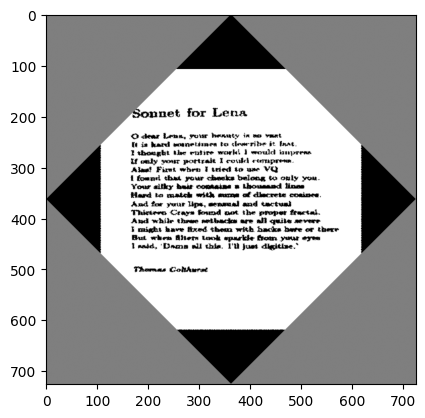

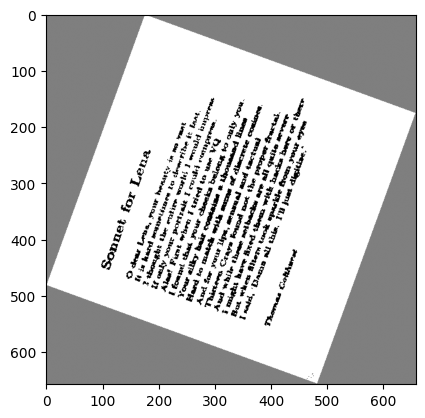

L'angle de rotation est de :  45.0


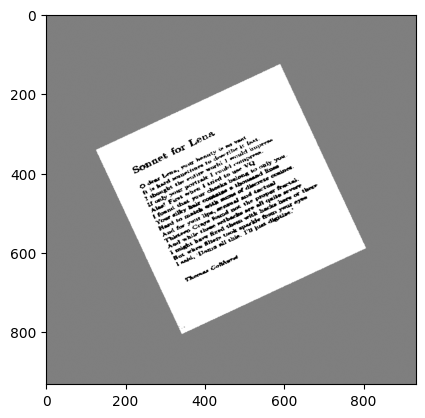

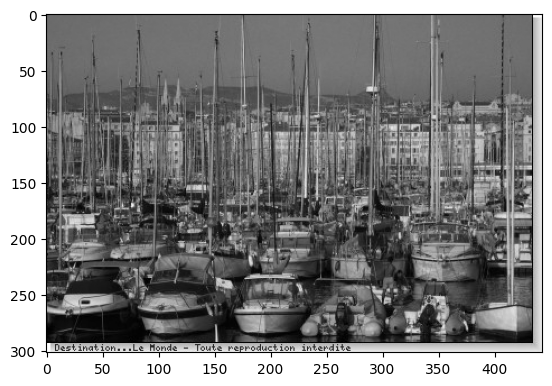

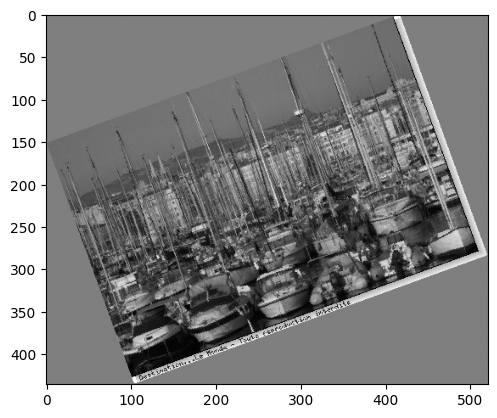

L'angle de rotation est de :  50.625


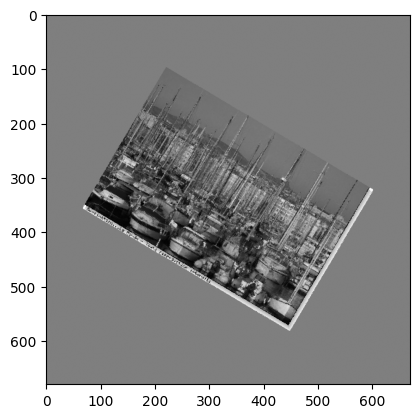

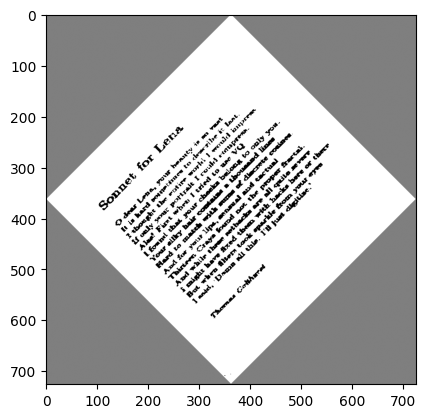

L'angle de rotation est de :  45.0


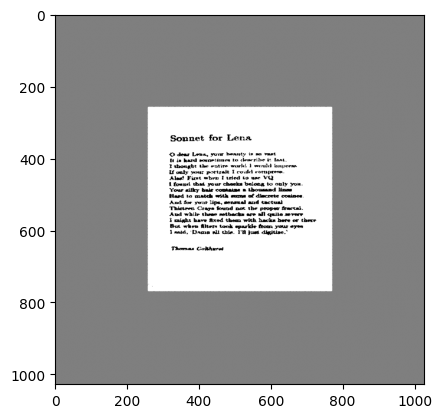

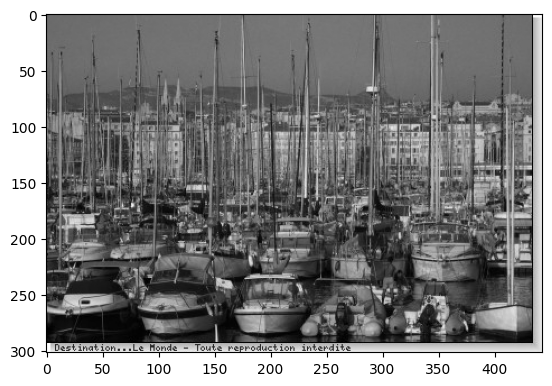

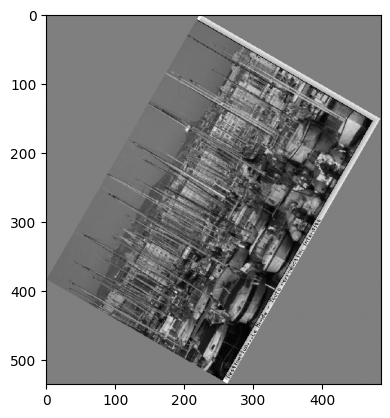

L'angle de rotation est de :  39.375


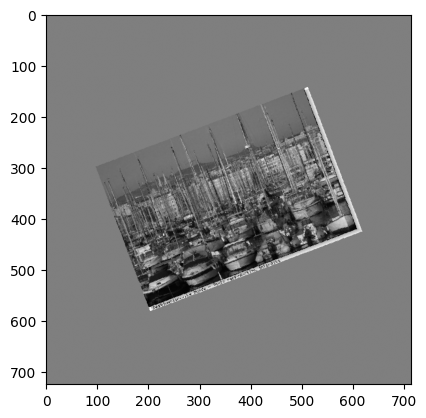

In [144]:
sonrot_rectified = rectifyOrientation(sonrot)
plt.imshow(sonrot_rectified)
plt.show()

son_rotated = rotateImage(son, 70)
plt.imshow(son_rotated)
plt.show()
son2_rectified = rectifyOrientation(son_rotated)
plt.imshow(son2_rectified)
plt.show()

port = np.array(Image.open('img/port.jpg'))
plt.imshow(port)
plt.show()

port_rotated = rotateImage(port, 20)
plt.imshow(port_rotated)
plt.show()
port_rectified = rectifyOrientation(port_rotated)
plt.imshow(port_rectified)
plt.show()


son_rotated = rotateImage(son, 45)
plt.imshow(son_rotated)
plt.show()
son2_rectified = rectifyOrientation(son_rotated)
plt.imshow(son2_rectified)
plt.show()

port = np.array(Image.open('img/port.jpg'))
plt.imshow(port)
plt.show()

port_rotated = rotateImage(port, 60)
plt.imshow(port_rotated)
plt.show()
port_rectified = rectifyOrientation(port_rotated)
plt.imshow(port_rectified)
plt.show()


# Avec une boucle test de la question 7 on voit bien qu'il y a un décalage entre mainOrientation et le vrai angle de la rotation de l'image
# pour toutes les valuers sauf 45. Donc la rectification parfaite n'est pas possible pour les angles ≠ 45. 
# Elle sera approximative à cause de la fonction mainOrientation. 